# DSAN 5650 Final Project

## Imports

In [1]:
import pandas as pd 
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import json
from pathlib import Path
import requests
from urllib.request import urlopen
import plotly.io as pio
import os
from ipumspy import IpumsApiClient, MicrodataExtract, readers, ddi
import plotly.graph_objs as go
import pymc as pm
import arviz as az
import re

pio.renderers.default = "notebook"

/opt/anaconda3/envs/MyNewEnv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [2]:
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

In [3]:
key_file_path = os.path.expanduser("~/api_keys.json")

with open(key_file_path, 'r') as file:
    api_key = json.load(file).get("ipums")

ipums = IpumsApiClient(api_key)

In [4]:
with open('/Users/Emi/api_keys.json') as f:
    api_keys = json.load(f)

## DOL Childcare Database
https://dataportal.dol.gov/datasets/10278

In [6]:
data = pd.read_excel("../assets/NDCP2022.xlsx")

In [7]:
data.columns

Index(['STATE_NAME', 'STATE_ABBREVIATION', 'COUNTY_NAME', 'COUNTY_FIPS_CODE',
       'STUDYYEAR', 'EMR_16', 'FEMR_16', 'MEMR_16', 'EMR_20to64',
       'FEMR_20to64',
       ...
       'iFEMP_SERVICE_STATE', 'iEMP_SALES_STATE', 'iMEMP_SALES_STATE',
       'iFEMP_SALES_STATE', 'iEMP_N_STATE', 'iMEMP_N_STATE', 'iFEMP_N_STATE',
       'iEMP_P_STATE', 'iMEMP_P_STATE', 'iFEMP_P_STATE'],
      dtype='object', length=370)

In [8]:
data.head()

,STATE_NAME,STATE_ABBREVIATION,COUNTY_NAME,COUNTY_FIPS_CODE,STUDYYEAR,EMR_16,FEMR_16,MEMR_16,EMR_20to64,FEMR_20to64,...,iFEMP_SERVICE_STATE,iEMP_SALES_STATE,iMEMP_SALES_STATE,iFEMP_SALES_STATE,iEMP_N_STATE,iMEMP_N_STATE,iFEMP_N_STATE,iEMP_P_STATE,iMEMP_P_STATE,iFEMP_P_STATE
0,Alabama,AL,Autauga County,1001,2008,61.5,56.1,67.3,71.4,66.3,...,1,1,1,1,1,1,1,1,1,1
1,Alabama,AL,Autauga County,1001,2009,60.6,54.8,67.0,72.5,66.9,...,1,1,1,1,1,1,1,1,1,1
2,Alabama,AL,Autauga County,1001,2010,60.4,54.9,66.4,72.3,67.4,...,1,1,1,1,1,1,1,1,1,1
3,Alabama,AL,Autauga County,1001,2011,58.7,52.4,65.6,71.0,64.9,...,1,1,1,1,1,1,1,1,1,1
4,Alabama,AL,Autauga County,1001,2012,57.7,52.2,63.8,70.7,65.1,...,1,1,1,1,1,1,1,1,1,1


In [9]:
sel_cols = ['STATE_NAME',
 'STATE_ABBREVIATION',
 'COUNTY_NAME',
 'COUNTY_FIPS_CODE',
 'STUDYYEAR',
 'MCBto5',
 'MC6to11',
 'MCINFANT',
 'MCTODDLER',
 'MCPRESCHOOL',
 'MFCCINFANT',
 'MFCCTODDLER',
 'MFCCPRESCHOOL',
 'FLFPR_20to64_UNDER6', # labor force participation rate of women with children under 6
 'FLFPR_20to64_6to17', # labor force participation rate of women with children 6 to 17
 'FLFPR_20to64_STATE', # womens lf participation rate by state,
 'FLFPR_20to64', # overall women's labor force participation rate (20-64) 
 'FME_2022', # median earnings for females in 2022 dollars
 'MME_2022', # median male earnings
 'MFI_2022'] # median family income in 2022

cc_df = data[sel_cols]

In [10]:
# Clean up colum names

col_replacement_dict = {
    'STATE_NAME': 'State Name',
    'STATE_ABBREVIATION': 'State Abbreviation',
    'COUNTY_NAME': 'County Name',
    'COUNTY_FIPS_CODE': 'County FIPS Code',
    'STUDYYEAR': 'Study Year',
    'MCBto5': 'Center-based care (0-5)',
    'MC6to11': 'Center-based care (6-11)',
    'MCINFANT': 'Center-based care (Infant)',
    'MCTODDLER': 'Center-based care (Toddler)',
    'MCPRESCHOOL': 'Center-based care (Preschool)',
    'MFCCINFANT': 'Family child care (Infant)',
    'MFCCTODDLER': 'Family child care (Toddler)',
    'MFCCPRESCHOOL': 'Family child care (Preschool)',
    'FLFPR_20to64_UNDER6': 'FLFP Rate (20-64) with children under 6',
    'FLFPR_20to64_6to17': 'FLFP Rate (20-64) with children 6 to 17',
    'FLFPR_20to64_STATE': 'FLFP Rate (20-64) by state',
    'FLFPR_20to64': 'FLFP Rate (20-64)',
    'MFI_2022': 'Median family income (2022)',
    'MME_2022':'Median Male earnings (2022)',
    'FME_2022':'Median Female earnings (2022)'
}

cc_df.rename(columns=col_replacement_dict, inplace=True)

/var/folders/t8/40bpmbs9559ck36zv79hp_b40000gn/T/ipykernel_6555/1881900288.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [11]:
cc_df.head()

,State Name,State Abbreviation,County Name,County FIPS Code,Study Year,Center-based care (0-5),Center-based care (6-11),Center-based care (Infant),Center-based care (Toddler),Center-based care (Preschool),Family child care (Infant),Family child care (Toddler),Family child care (Preschool),FLFP Rate (20-64) with children under 6,FLFP Rate (20-64) with children 6 to 17,FLFP Rate (20-64) by state,FLFP Rate (20-64),Median Female earnings (2022),Median Male earnings (2022),Median family income (2022)
0,Alabama,AL,Autauga County,1001,2008,104.95,104.95,104.95,104.95,85.92,83.45,83.45,81.40,66.9,79.6,68.6,68.9,29531,48643,82700
1,Alabama,AL,Autauga County,1001,2009,105.11,105.11,105.11,105.11,87.59,87.39,87.39,85.68,63.7,78.4,68.0,70.8,31443,51364,86937
2,Alabama,AL,Autauga County,1001,2010,105.28,105.28,105.28,105.28,89.26,91.33,91.33,89.96,67.0,78.2,67.3,71.3,32114,54113,87409
3,Alabama,AL,Autauga County,1001,2011,105.45,105.45,105.45,105.45,90.93,95.28,95.28,94.25,66.5,77.6,67.7,70.2,31262,53024,86075
4,Alabama,AL,Autauga County,1001,2012,105.61,105.61,105.61,105.61,92.60,99.22,99.22,98.53,67.1,76.3,66.2,70.6,32798,51924,86322


In [12]:
cc_df['County FIPS Code'] = cc_df['County FIPS Code'].astype(str).str.zfill(5)

/var/folders/t8/40bpmbs9559ck36zv79hp_b40000gn/T/ipykernel_6555/3958202008.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Bring in General ACS Data

In [13]:
census_key = api_keys['census']

In [14]:
base_url = "https://api.census.gov/data/2022/acs/acs5"

variables = ["NAME", # county name
    "B01003_001E",  # Total county population"
    "B06009_005E",  # Total: bachelor's degree
    "B06009_001E",  # Total population age 25+
    "B06009_006E",  # Total: graduate or professional degree
    "B06009_011E",  # Born in current state: bachelor's degree
    "B06009_012E"]  # Born in current state: graduate/professional degree

# Get the list of state FIPS codes.
state_params = {"get": "NAME","for": "state:*","key":census_key}

state_response = requests.get(base_url, params=state_params,timeout=30)
state_response.raise_for_status()    

data = state_response.json()
state_json = state_response.json()
states = pd.DataFrame(state_json[1:],columns=state_json[0])

# exclude puerto rico
states = states.loc[states["state"] != "72"].copy()

county_frames = []

for state_fips in states["state"]:
    params = {
        "get": ",".join(variables),
        "for": "county:*",
        "in": f"state:{state_fips}",
        "key":census_key
    }

    response = requests.get(base_url,params=params,timeout=30)
    response.raise_for_status()

    data = response.json()

    county_frames.append(pd.DataFrame(data[1:],columns=data[0]))

counties = pd.concat(county_frames,ignore_index=True)

counties = counties.rename(columns={
        "B06009_005E": "bachelors_total",
        "B06009_006E": "graduate_professional_total",
        "B06009_011E": "bachelors_born_in_state",
        "B06009_012E": "graduate_professional_born_in_state",
        "B06009_001E": "total_pop_25_over",
        "B01003_001E": "total_county_pop"})

In [15]:
# convert numeric cols to numeric
target_cols = [col for col in counties.columns if col not in ['NAME','county','state']]

counties[target_cols] = counties[target_cols].apply(pd.to_numeric, errors='coerce')

In [16]:
# create fips codes
counties["county_fips"] = (counties["state"].str.zfill(2) + counties["county"].str.zfill(3))

counties["bachelors_plus_total"] = (counties["bachelors_total"].astype('int') + counties["graduate_professional_total"]).astype('int')
counties["bachelors_plus_born_in_state"] = (counties["bachelors_born_in_state"]+ counties["graduate_professional_born_in_state"])

# get share of 25+ adults with at least bachelors as education measure
counties["bachelors_plus_share"] = (counties["bachelors_plus_total"] / counties["total_pop_25_over"])

# how many adults with at least bachelors live in the state they were born in vs. move to another state (presumably for career)
counties["state_rooted_bachelors_plus"] = (counties["bachelors_plus_born_in_state"] / counties["bachelors_plus_total"]).where(counties["bachelors_plus_total"] > 0)
counties["state_rooted_bachelors_plus_pct"] = (counties["state_rooted_bachelors_plus"] * 100)

In [17]:
counties.head()

,NAME,total_county_pop,bachelors_total,total_pop_25_over,graduate_professional_total,bachelors_born_in_state,graduate_professional_born_in_state,state,county,county_fips,bachelors_plus_total,bachelors_plus_born_in_state,bachelors_plus_share,state_rooted_bachelors_plus,state_rooted_bachelors_plus_pct
0,"Autauga County, Alabama",58761,6726,40188,5153,3652,2074,01,001,01001,11879,5726,0.295586,0.482027,48.202711
1,"Baldwin County, Alabama",233420,33474,167022,20911,14119,8098,01,003,01003,54385,22217,0.325616,0.408513,40.851338
2,"Barbour County, Alabama",24877,1167,17675,933,667,607,01,005,01005,2100,1274,0.118812,0.606667,60.666667
3,"Bibb County, Alabama",22251,1047,15925,692,797,368,01,007,01007,1739,1165,0.109199,0.669925,66.992524
4,"Blount County, Alabama",59077,3840,40817,2177,2944,1764,01,009,01009,6017,4708,0.147414,0.782450,78.244973


###  Get land area to calculate population density

In [18]:
county_area = pd.read_csv(
    "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2022_Gazetteer/2022_Gaz_counties_national.zip",
    sep="\t",
    compression="zip",
    dtype={"GEOID": str},
)

county_area["GEOID"] = county_area["GEOID"].str.zfill(5)
county_area = county_area[['GEOID','ALAND_SQMI']]

In [19]:
county_area.head()

,GEOID,ALAND_SQMI
0,01001,594.455
1,01003,1589.863
2,01005,885.008
3,01007,622.470
4,01009,644.891


In [20]:
counties = pd.merge(counties, county_area, how='left', left_on='county_fips',right_on="GEOID").drop(columns='GEOID')

In [21]:
counties.head()

,NAME,total_county_pop,bachelors_total,total_pop_25_over,graduate_professional_total,bachelors_born_in_state,graduate_professional_born_in_state,state,county,county_fips,bachelors_plus_total,bachelors_plus_born_in_state,bachelors_plus_share,state_rooted_bachelors_plus,state_rooted_bachelors_plus_pct,ALAND_SQMI
0,"Autauga County, Alabama",58761,6726,40188,5153,3652,2074,01,001,01001,11879,5726,0.295586,0.482027,48.202711,594.455
1,"Baldwin County, Alabama",233420,33474,167022,20911,14119,8098,01,003,01003,54385,22217,0.325616,0.408513,40.851338,1589.863
2,"Barbour County, Alabama",24877,1167,17675,933,667,607,01,005,01005,2100,1274,0.118812,0.606667,60.666667,885.008
3,"Bibb County, Alabama",22251,1047,15925,692,797,368,01,007,01007,1739,1165,0.109199,0.669925,66.992524,622.470
4,"Blount County, Alabama",59077,3840,40817,2177,2944,1764,01,009,01009,6017,4708,0.147414,0.782450,78.244973,644.891


In [22]:
counties['pop_density'] = counties['total_county_pop'] / counties['ALAND_SQMI']

## ACS Series s2402
https://data.census.gov/table/ACSST5Y2023.S2402

Occupation by Sex for the Full-Time, Year-Round Civilian Employed Population 16 Years and Over

In [23]:
def census_json_request(url,params,timeout=60):
    response = requests.get(
        url,
        params=params,
        timeout=timeout,
    )
    response.raise_for_status()

    return response.json()

def get_county_female_occupation_counts(table_id):
    base_url = (f"https://api.census.gov/data/2022/acs/acs5/subject")

    metadata_params = {}
    metadata_params["key"] = census_key

    response = requests.get(f"{base_url}/groups/{table_id}.json" ,params=metadata_params,timeout=30)
    response.raise_for_status()
    metadata = response.json()

    all_variables = metadata["variables"]
    female_variables = {
        variable: details["label"]
        for variable, details in all_variables.items()
        if variable.startswith(f"{table_id}_")
        and variable.endswith("E")
        and details.get("label", "").startswith("Estimate!!Female!!")
    }

    def variable_number(variable):
        match = re.search(r"_(\d{3})E$", variable)
        return int(match.group(1)) if match else 9999

    female_codes = sorted(
        female_variables,
        key=variable_number,
    )

    total_female_code = f"{table_id}_C04_001E"

    requested_variables = ["NAME", *female_codes]

    state_data = census_json_request(
        url=base_url,
        params={ "get": "NAME",
        "for": "state:*",
        "key":census_key})

    states = pd.DataFrame(state_data[1:],columns=state_data[0])
    states = states.loc[states["state"] != "72"].copy()

    county_frames = []

    for state_fips in states["state"]:
        data = census_json_request(
            url=base_url,
            params={
            "get": ",".join(requested_variables),
            "for": "county:*",
            "in": f"state:{state_fips}",
            "key":census_key})

        county_frames.append(pd.DataFrame(data[1:],columns=data[0]))

    occupation_df = pd.concat(county_frames,ignore_index=True)

    # replace values below 0 with blanks
    occupation_df[female_codes] = occupation_df[female_codes].apply(pd.to_numeric,errors="coerce")
    occupation_df[female_codes] = occupation_df[female_codes].mask(occupation_df[female_codes] < 0)

    occupation_df["county_fips"] = (occupation_df["state"].str.zfill(2)+ occupation_df["county"].str.zfill(3))

    occupation_df = occupation_df.rename(columns={total_female_code: "female_employed_total"})

    renamed_female_codes = ["female_employed_total" if code == total_female_code else code for code in female_codes]

    denominator = occupation_df["female_employed_total"].replace(0, pd.NA)

    for original_code, current_code in zip(female_codes,renamed_female_codes):
        if current_code == "female_employed_total":
            continue
        occupation_df[f"{current_code}_share"] = occupation_df[current_code] / denominator

    variable_dictionary = pd.DataFrame({"variable": female_codes,"label": [female_variables[code] for code in female_codes]})
    variable_dictionary["occupation"] = (variable_dictionary["label"].str.split("!!").str[-1].str.rstrip(":"))
    variable_dictionary["is_total"] = (variable_dictionary["variable"]== total_female_code)

    return occupation_df, variable_dictionary

In [24]:
s2402_df, s2402_dictionary = (get_county_female_occupation_counts(table_id="S2402"))

s2402_df.head()

,NAME,female_employed_total,S2402_C04_002E,S2402_C04_003E,S2402_C04_004E,S2402_C04_005E,S2402_C04_006E,S2402_C04_007E,S2402_C04_008E,S2402_C04_009E,...,S2402_C04_027E_share,S2402_C04_028E_share,S2402_C04_029E_share,S2402_C04_030E_share,S2402_C04_031E_share,S2402_C04_032E_share,S2402_C04_033E_share,S2402_C04_034E_share,S2402_C04_035E_share,S2402_C04_036E_share
0,"Autauga County, Alabama",8931,4468,1601,871,730,418,333,48,37,...,0.074236,0.223491,0.011197,0.004367,0.003359,0.003471,0.068413,0.029336,0.006830,0.032247
1,"Baldwin County, Alabama",33658,15711,4715,3359,1356,801,313,299,189,...,0.111504,0.198051,0.010339,0.001931,0.007131,0.001278,0.061947,0.038297,0.007754,0.015895
2,"Barbour County, Alabama",3064,1113,305,189,116,95,67,6,22,...,0.072781,0.202676,0.026762,0.026762,0.000000,0.000000,0.152742,0.087141,0.008486,0.057115
3,"Bibb County, Alabama",2393,830,224,171,53,48,14,0,34,...,0.082323,0.190556,0.001254,0.000000,0.001254,0.000000,0.178855,0.131216,0.025909,0.021730
4,"Blount County, Alabama",7315,3088,910,697,213,91,63,2,26,...,0.089132,0.232673,0.006015,0.001777,0.001640,0.002597,0.127820,0.080656,0.013944,0.033219


In [25]:
replace_dict = dict(zip(s2402_dictionary['variable'], s2402_dictionary['occupation']))

clean_s2402_df = s2402_df.rename(columns=replace_dict)

def replace_all(text, dic):
    for old, new in dic.items():
        text = text.replace(old, new)
    return text

# Reassign column names
clean_s2402_df.columns = [replace_all(col, replace_dict) for col in clean_s2402_df.columns]

In [26]:
clean_s2402_df.columns

Index(['NAME', 'female_employed_total',
       'Management, business, science, and arts occupations',
       'Management, business, and financial occupations',
       'Management occupations',
       'Business and financial operations occupations',
       'Computer, engineering, and science occupations',
       'Computer and mathematical occupations',
       'Architecture and engineering occupations',
       'Life, physical, and social science occupations',
       'Education, legal, community service, arts, and media occupations',
       'Community and social service occupations', 'Legal occupations',
       'Educational instruction, and library occupations',
       'Arts, design, entertainment, sports, and media occupations',
       'Healthcare practitioners and technical occupations',
       'Health diagnosing and treating practitioners and other technical occupations',
       'Health technologists and technicians', 'Service occupations',
       'Healthcare support occupations', 'Pro

In [27]:
goldin_occupations = ['NAME','Management occupations_share','Legal occupations_share',
'Business and financial operations occupations_share',
'Computer and mathematical occupations_share','Life, physical, and social science occupations_share',
'Educational instruction, and library occupations_share',
'Health diagnosing and treating practitioners and other technical occupations_share']

In [28]:
clean_s2402_df[goldin_occupations]

,NAME,Management occupations_share,Legal occupations_share,Business and financial operations occupations_share,Computer and mathematical occupations_share,"Life, physical, and social science occupations_share","Educational instruction, and library occupations_share",Health diagnosing and treating practitioners and other technical occupations_share
0,"Autauga County, Alabama",0.097525,0.006270,0.081738,0.037286,0.004143,0.117680,0.054417
1,"Baldwin County, Alabama",0.099798,0.014380,0.040288,0.009299,0.005615,0.118724,0.098966
2,"Barbour County, Alabama",0.061684,0.004243,0.037859,0.021867,0.007180,0.110966,0.070822
3,"Bibb County, Alabama",0.071458,0.010029,0.022148,0.005850,0.014208,0.069369,0.081070
4,"Blount County, Alabama",0.095284,0.016951,0.029118,0.008612,0.003554,0.098018,0.089405
...,...,...,...,...,...,...,...,...
3139,"Sweetwater County, Wyoming",0.108874,0.009622,0.059515,0.007306,0.014968,0.082324,0.073592
3140,"Teton County, Wyoming",0.165594,0.015799,0.056173,0.009362,0.011410,0.069631,0.040667
3141,"Uinta County, Wyoming",0.082759,0.000000,0.063286,0.000000,0.004057,0.107911,0.081542
3142,"Washakie County, Wyoming",0.085667,0.000000,0.030478,0.000000,0.032125,0.108731,0.107084


In [29]:
goldin_greedy_cols = [
    "Management occupations_share",
    "Legal occupations_share",
    "Business and financial operations occupations_share",
]

clean_s2402_df["greedy_profession_share"] = clean_s2402_df[goldin_greedy_cols].sum(axis=1)

## Preparing Data

In [30]:
len(counties)

3144

In [31]:
joined = pd.merge(counties, clean_s2402_df, how='left',on='county_fips')
len(joined)

3144

In [32]:
cc_df_2022 = cc_df[cc_df['Study Year'].eq(2022)]

merged = pd.merge(joined, cc_df_2022, how='left', left_on='county_fips', right_on='County FIPS Code')
len(merged)

3144

## EDA

In [33]:
list(merged.columns)

['NAME_x',
 'total_county_pop',
 'bachelors_total',
 'total_pop_25_over',
 'graduate_professional_total',
 'bachelors_born_in_state',
 'graduate_professional_born_in_state',
 'state_x',
 'county_x',
 'county_fips',
 'bachelors_plus_total',
 'bachelors_plus_born_in_state',
 'bachelors_plus_share',
 'state_rooted_bachelors_plus',
 'state_rooted_bachelors_plus_pct',
 'ALAND_SQMI',
 'pop_density',
 'NAME_y',
 'female_employed_total',
 'Management, business, science, and arts occupations',
 'Management, business, and financial occupations',
 'Management occupations',
 'Business and financial operations occupations',
 'Computer, engineering, and science occupations',
 'Computer and mathematical occupations',
 'Architecture and engineering occupations',
 'Life, physical, and social science occupations',
 'Education, legal, community service, arts, and media occupations',
 'Community and social service occupations',
 'Legal occupations',
 'Educational instruction, and library occupations',
 'A

In [44]:
analysis_cols = [
    'FLFP Rate (20-64) with children under 6',
    'FLFP Rate (20-64)',
    'Center-based care (0-5)',
    'Center-based care (6-11)',
    'Center-based care (Infant)',
    'Center-based care (Toddler)',
    'Center-based care (Preschool)',
    "greedy_profession_share",
    "bachelors_plus_share",
    "Median family income (2022)",
    "pop_density",
    "state_rooted_bachelors_plus",
]

merged[analysis_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2653 entries, 0 to 3143
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   FLFP Rate (20-64) with children under 6  2653 non-null   float64
 1   FLFP Rate (20-64)                        2653 non-null   float64
 2   Center-based care (0-5)                  2653 non-null   float64
 3   Center-based care (6-11)                 2653 non-null   float64
 4   Center-based care (Infant)               2653 non-null   float64
 5   Center-based care (Toddler)              2651 non-null   float64
 6   Center-based care (Preschool)            2653 non-null   float64
 7   greedy_profession_share                  2653 non-null   float64
 8   bachelors_plus_share                     2653 non-null   float64
 9   Median family income (2022)              2653 non-null   float64
 10  pop_density                              2653 non-nul

In [51]:
merged[["Center-based care (0-5)", "FLFP Rate (20-64) with children under 6"]].dropna().corr()

,Center-based care (0-5),FLFP Rate (20-64) with children under 6
Center-based care (0-5),1.000000,0.099472
FLFP Rate (20-64) with children under 6,0.099472,1.000000


## PGM

In [35]:
merged = merged[~merged['FLFP Rate (20-64) with children under 6'].isna()]
merged = merged[~merged['Center-based care (0-5)'].isna()]

In [36]:
list(merged.columns)

['NAME_x',
 'total_county_pop',
 'bachelors_total',
 'total_pop_25_over',
 'graduate_professional_total',
 'bachelors_born_in_state',
 'graduate_professional_born_in_state',
 'state_x',
 'county_x',
 'county_fips',
 'bachelors_plus_total',
 'bachelors_plus_born_in_state',
 'bachelors_plus_share',
 'state_rooted_bachelors_plus',
 'state_rooted_bachelors_plus_pct',
 'ALAND_SQMI',
 'pop_density',
 'NAME_y',
 'female_employed_total',
 'Management, business, science, and arts occupations',
 'Management, business, and financial occupations',
 'Management occupations',
 'Business and financial operations occupations',
 'Computer, engineering, and science occupations',
 'Computer and mathematical occupations',
 'Architecture and engineering occupations',
 'Life, physical, and social science occupations',
 'Education, legal, community service, arts, and media occupations',
 'Community and social service occupations',
 'Legal occupations',
 'Educational instruction, and library occupations',
 'A

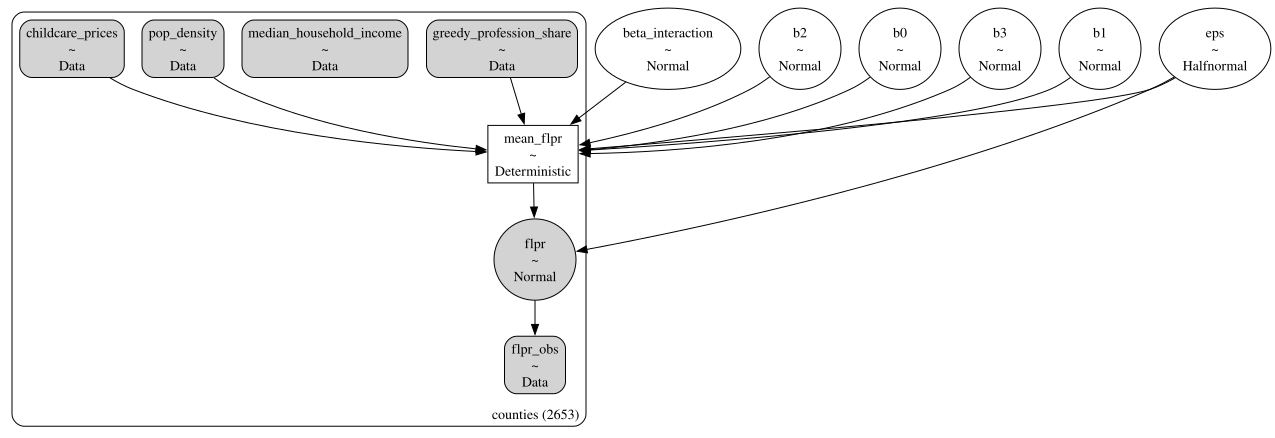

In [ ]:
coords = {
  'counties': merged.county_fips,
}

# with the context of this model, create these variables
with pm.Model(coords=coords) as model:
    # Observed Data
    # X node
    greedy_profession_share = pm.Data(
        "greedy_profession_share",
        merged['greedy_profession_share'],
        dims='counties',
      )

    childcare_prices = pm.Data(
            "childcare_prices",
            merged['Center-based care (0-5)'],
            dims='counties',
          )

    pop_density = pm.Data(
            "pop_density",
            merged['pop_density'],
            dims='counties',
          )

    median_household_income = pm.Data(
        "median_household_income",
        merged["Median family income (2022)"],
        dims='counties'
    )

    # Y node
    flpr_obs = pm.Data(
      "flpr_obs", # can be named anything but best to name the same as python variable
      merged['FLFP Rate (20-64) with children under 6'],
      dims='counties',
    )

    # Parameters
    b0 = pm.Normal('b0', mu=8, sigma=0.5)
    b1 = pm.Normal("b1", mu=0, sigma=0.5)
    b2 = pm.Normal("b2", mu=0, sigma=0.5)
    b3 = pm.Normal("b3", mu=0, sigma=0.5)
    beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=0.5)
    eps = pm.HalfNormal("eps", sigma=4)

    # Linking them together!
    mean_flpr = pm.Deterministic(
      'mean_flpr',
      b0 + (b1 * childcare_prices) + 
      (b2 * greedy_profession_share) + 
      (beta_interaction * childcare_prices * greedy_profession_share) +
      (b3 * pop_density) +
      eps,
      dims='counties',
    )

    flpr = pm.Normal(
      'flpr',
      mu=mean_flpr, sigma=eps,
      observed=flpr_obs, # observed is the thing you want the model to learn --> we compare against the actual gdp we observed in the df
      dims='counties',
    )

model.to_graphviz() #visualizes model

In [38]:
with model:
  idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, b2, b3, beta_interaction, eps]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


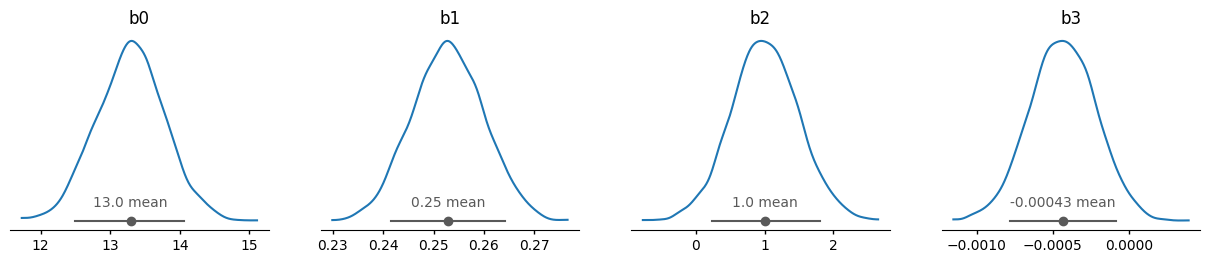

In [39]:
az.plot_dist(
  idata.posterior,
  var_names=['b0','b1','b2','b3'],
);
plt.show()